<a href="https://colab.research.google.com/github/tusharviradiya/ai-ml/blob/main/11_Practice/week4/Unsupervised_ML_Problems_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

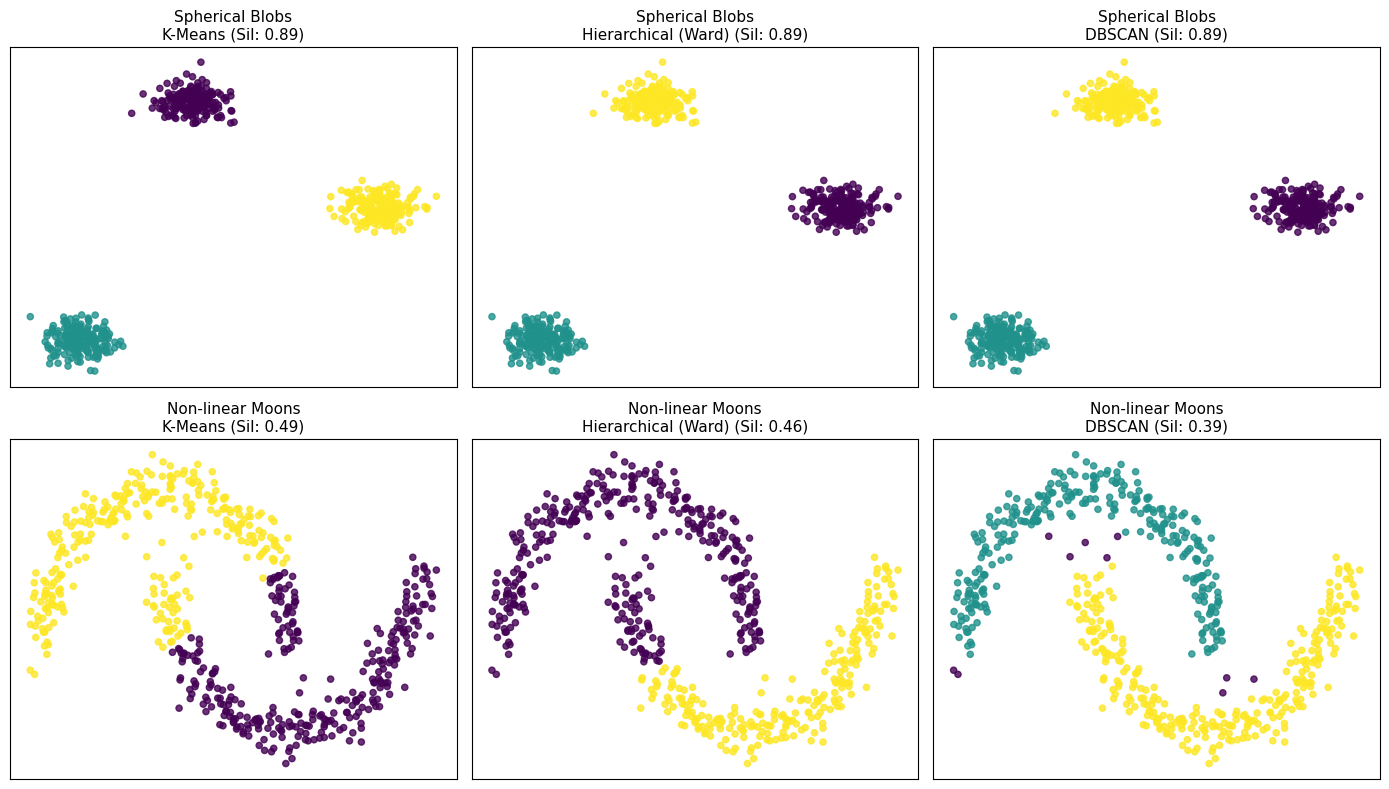

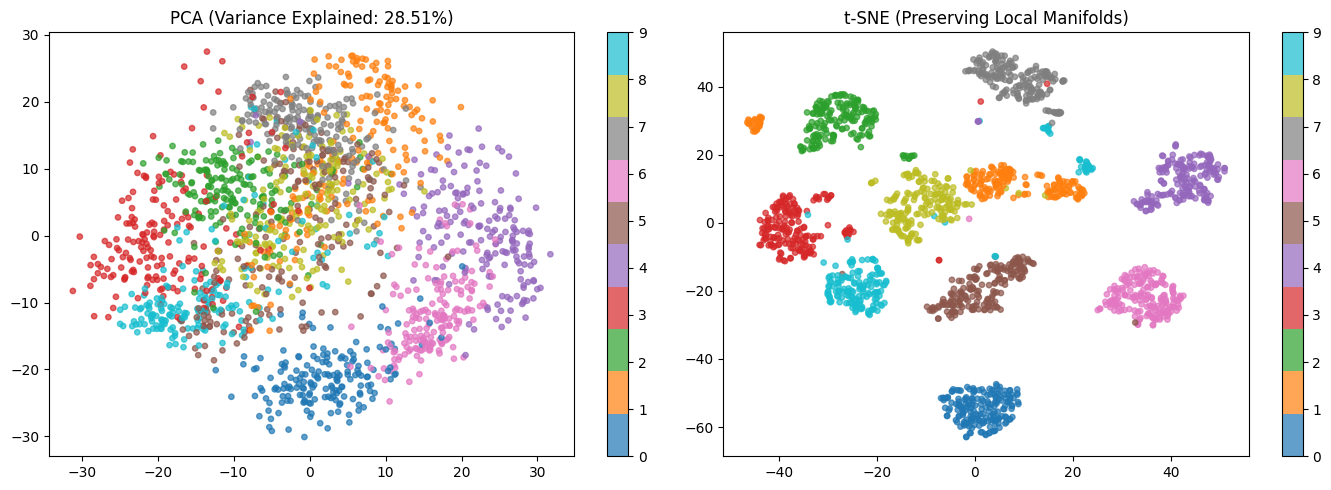

In [1]:
# ==============================================================================
# 1. SETUP & CLUSTERING ALGORITHMS COMPARISON
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import load_digits, make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Generate synthetic datasets: Spherical Blobs vs Non-linear Moons
X_blobs, _ = make_blobs(n_samples=600, centers=3, cluster_std=0.7, random_state=42)
X_moons, _ = make_moons(n_samples=600, noise=0.08, random_state=42)

datasets = [("Spherical Blobs", X_blobs), ("Non-linear Moons", X_moons)]
clustering_algorithms = {
    "K-Means": lambda X: KMeans(n_clusters=3 if "Blobs" in dname else 2, random_state=42, n_init=10).fit_predict(X),
    "Hierarchical (Ward)": lambda X: AgglomerativeClustering(n_clusters=3 if "Blobs" in dname else 2).fit_predict(X),
    "DBSCAN": lambda X: DBSCAN(eps=0.3 if "Blobs" in dname else 0.2, min_samples=5).fit_predict(X)
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, (dname, X) in enumerate(datasets):
    X_scaled = StandardScaler().fit_transform(X)
    for col_idx, (aname, model_func) in enumerate(clustering_algorithms.items()):
        labels = model_func(X_scaled)

        # Calculate silhouette score (ignore noise labeled as -1 for DBSCAN)
        valid_mask = labels != -1
        score = silhouette_score(X_scaled[valid_mask], labels[valid_mask]) if len(set(labels[valid_mask])) > 1 else np.nan

        ax = axes[row_idx, col_idx]
        scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="viridis", s=20, alpha=0.8)
        ax.set_title(f"{dname}\n{aname} (Sil: {score:.2f})", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. DIMENSIONALITY REDUCTION: PCA vs t-SNE
# ==============================================================================
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_digits)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap="tab10", s=15, alpha=0.7)
axes[0].set_title(f"PCA (Variance Explained: {pca.explained_variance_ratio_.sum():.2%})", fontsize=12)
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap="tab10", s=15, alpha=0.7)
axes[1].set_title("t-SNE (Preserving Local Manifolds)", fontsize=12)
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()